# 5. Bi-TCN Kaggle Employee Churn Training

Notebook này áp dụng kiến trúc **Bi-TCN** đã thử nghiệm trên IBM HR Analytics sang **Kaggle Employee Churn Dataset** để đánh giá tính tổng quát trên quy mô lớn hơn.

Vai trò dataset Kaggle trong đồ án:

- Đánh giá độc lập khả năng tổng quát của Bi-TCN
- Không dùng augmentation / oversampling
- Vẫn dùng Stratified 5-Fold Cross Validation
- Fit preprocessing chỉ trên train fold
- Lưu checkpoint, metrics, confusion matrix, ROC/PR curves
- Bắt buộc có biểu đồ **training loss vs validation loss** và **training accuracy vs validation accuracy**


## 1. Project Setup


In [23]:
import importlib.util
import math
import os
import random
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
import copy
import json

REQUIRED_PACKAGES = {
    "torch": "torch",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
}
missing_packages = [
    pip_name for import_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]
if missing_packages:
    print("Missing packages:", ", ".join(missing_packages))
    print("Install in this notebook environment with:")
    print("%pip install " + " ".join(missing_packages))
    raise ImportError("Install the missing packages above, then restart the kernel and rerun this notebook.")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
 )
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "processed" / "Kaggle_Cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/processed/Kaggle_Cleaned.csv")

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "Kaggle_Cleaned.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "bitcn_kaggle"
MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"

for path in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, LOG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

@dataclass
class Config:
    seed: int = 42
    n_splits: int = 5
    target_col: str = "Churn"
    augmentation: str = "NONE"
    batch_size: int = 32
    epochs: int = 120
    patience: int = 25
    lr: float = 5e-4
    weight_decay: float = 5e-5
    input_noise_std: float = 0.0
    dropout: float = 0.35
    stem_channels: int = 16
    filters_1: int = 32
    filters_2: int = 64
    hidden_dim: int = 96
    attention_reduction: int = 8
    threshold_metric: str = "f1"
    selection_metric: str = "f1"
    num_workers: int = 0
    use_amp: bool = True
    loss_type: str = "bce"
    pos_weight_strategy: str = "sqrt"
    max_pos_weight: float = 4.0
    focal_gamma: float = 2.0

CFG = Config()

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

seed_everything(CFG.seed)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
AMP_ENABLED = CFG.use_amp and DEVICE.type == "cuda"

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print("Augmentation: NONE. Kaggle is used for generalization testing.")
print(json.dumps(asdict(CFG), indent=2))

with open(OUTPUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)


Project root: F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN
Device: cpu
Augmentation: NONE. Kaggle is used for generalization testing.
{
  "seed": 42,
  "n_splits": 5,
  "target_col": "Churn",
  "augmentation": "NONE",
  "batch_size": 32,
  "epochs": 120,
  "patience": 25,
  "lr": 0.0005,
  "weight_decay": 5e-05,
  "input_noise_std": 0.0,
  "dropout": 0.35,
  "stem_channels": 16,
  "filters_1": 32,
  "filters_2": 64,
  "hidden_dim": 96,
  "attention_reduction": 8,
  "threshold_metric": "f1",
  "selection_metric": "f1",
  "num_workers": 0,
  "use_amp": true,
  "loss_type": "bce",
  "pos_weight_strategy": "sqrt",
  "max_pos_weight": 4.0,
  "focal_gamma": 2.0
}


## 2. Load Kaggle Dataset


In [24]:
df = pd.read_csv(DATA_PATH)

if CFG.target_col not in df.columns:
    raise ValueError(f"Expected target column '{CFG.target_col}', found columns: {list(df.columns)}")

print("Dataset shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicated rows:", int(df.duplicated().sum()))
print("\nClass distribution:")
print(df[CFG.target_col].value_counts().sort_index())
print("\nClass ratio:")
print((df[CFG.target_col].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + "%")
display(df.head())


Dataset shape: (10000, 32)
Missing values: 0
Duplicated rows: 0

Class distribution:
Churn
0    7972
1    2028
Name: count, dtype: int64

Class ratio:
Churn
0    79.72%
1    20.28%
Name: proportion, dtype: str


,Age,Tenure,Salary,Performance Rating,Projects Completed,Training Hours,Promotions,Overtime Hours,Satisfaction Level,Average Monthly Hours Worked,...,Marital Status_Married,Marital Status_Single,Job Role_Developer,Job Role_Manager,Job Role_Sales,Work Location_On-site,Work Location_Remote,Work-Life Balance_Excellent,Work-Life Balance_Good,Work-Life Balance_Poor
0,0.756757,0.357143,0.528508,1.00,0.755102,0.353535,0.0,0.326531,0.03,0.033557,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.378378,0.285714,0.121509,0.25,0.877551,0.010101,0.0,0.244898,0.39,0.080537,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.189189,0.214286,0.223015,0.00,0.775510,0.414141,0.0,0.040816,0.62,0.624161,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.540541,0.857143,0.408383,0.00,0.795918,0.333333,0.0,0.163265,0.73,0.946309,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.486486,0.071429,0.433161,0.50,1.000000,0.303030,0.0,0.265306,0.52,0.818792,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


## 3. Feature / Target Split


In [25]:
X_df = df.drop(columns=[CFG.target_col]).copy()
y = df[CFG.target_col].astype(int).to_numpy()

if not set(np.unique(y)).issubset({0, 1}):
    raise ValueError("Churn target must be binary encoded as 0/1.")

feature_names = X_df.columns.tolist()
X_raw = X_df.astype("float32").to_numpy()
n_features = X_raw.shape[1]

print(f"Samples: {X_raw.shape[0]}")
print(f"Features / TCN sequence length: {n_features}")
print("TCN input shape: (batch, 1, num_features)")


Samples: 10000
Features / TCN sequence length: 31
TCN input shape: (batch, 1, num_features)


## 4. Metrics and DataLoader Helpers


In [26]:
def find_best_threshold(y_true: np.ndarray, y_prob: np.ndarray, metric: str = "f1"):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0
    precision = precision[:-1]
    recall = recall[:-1]
    scores = 2 * precision * recall / (precision + recall + 1e-12)
    best_idx = int(np.nanargmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])

def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "threshold": threshold,
    }

def summarize_metrics(rows: list[dict]) -> pd.DataFrame:
    df_metrics = pd.DataFrame(rows)
    metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "threshold", "best_epoch"]
    summary = df_metrics[metric_cols].agg(["mean", "std"]).T
    summary["mean_std"] = summary.apply(lambda r: f"{r['mean']:.4f} +/- {r['std']:.4f}", axis=1)
    return summary

def to_tcn_tensor(X_2d: np.ndarray) -> torch.Tensor:
    return torch.tensor(X_2d.reshape(X_2d.shape[0], 1, X_2d.shape[1]), dtype=torch.float32)

def make_loader(X_2d: np.ndarray, y_1d: np.ndarray, train: bool) -> DataLoader:
    dataset = TensorDataset(
        to_tcn_tensor(X_2d),
        torch.tensor(y_1d.reshape(-1, 1), dtype=torch.float32),
    )
    return DataLoader(
        dataset,
        batch_size=CFG.batch_size,
        shuffle=train,
        num_workers=CFG.num_workers,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )


## 5. Bi-TCN Architecture


In [27]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size: int):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.final_relu = nn.ReLU()

    def forward(self, x):
        return self.final_relu(self.net(x) + self.downsample(x))


class TemporalConvNet(nn.Module):
    def __init__(self, in_channels: int, channels: list[int], kernel_size: int, dilation: int, dropout: float):
        super().__init__()
        layers = []
        current_channels = in_channels
        for out_channels in channels:
            layers.append(TemporalBlock(current_channels, out_channels, kernel_size, dilation, dropout))
            current_channels = out_channels
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        weights = self.pool(x).squeeze(-1)
        weights = self.fc(weights).unsqueeze(-1)
        return x * weights


class GaussianNoise(nn.Module):
    def __init__(self, std: float = 0.0):
        super().__init__()
        self.std = std

    def forward(self, x):
        if self.training and self.std > 0:
            return x + torch.randn_like(x) * self.std
        return x


class BiTCNClassifier(nn.Module):
    def __init__(
        self,
        in_channels: int = 1,
        stem_channels: int = 16,
        filters_1: int = 32,
        filters_2: int = 64,
        hidden_dim: int = 96,
        dropout: float = 0.35,
        input_noise_std: float = 0.005,
        attention_reduction: int = 8,
    ):
        super().__init__()
        self.input_noise = GaussianNoise(input_noise_std)
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, stem_channels, kernel_size=1),
            nn.BatchNorm1d(stem_channels),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        # Same Bi-TCN paper core as the IBM notebook:
        # block 1: kernel=3, dilation=1; block 2: kernel=5, dilation=2.
        self.forward_k3 = TemporalConvNet(stem_channels, [filters_1, filters_1], kernel_size=3, dilation=1, dropout=dropout)
        self.backward_k3 = TemporalConvNet(stem_channels, [filters_1, filters_1], kernel_size=3, dilation=1, dropout=dropout)
        self.forward_k5 = TemporalConvNet(filters_1 * 2, [filters_2, filters_2], kernel_size=5, dilation=2, dropout=dropout)
        self.backward_k5 = TemporalConvNet(filters_1 * 2, [filters_2, filters_2], kernel_size=5, dilation=2, dropout=dropout)

        merged_channels = filters_2 * 2
        self.attention = ChannelAttention(merged_channels, reduction=attention_reduction)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(merged_channels * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x):
        x = self.input_noise(x)
        x = self.stem(x)
        x_rev = torch.flip(x, dims=[-1])
        f1 = self.forward_k3(x)
        b1 = torch.flip(self.backward_k3(x_rev), dims=[-1])
        stage1 = torch.cat([f1, b1], dim=1)

        stage1_rev = torch.flip(stage1, dims=[-1])
        f2 = self.forward_k5(stage1)
        b2 = torch.flip(self.backward_k5(stage1_rev), dims=[-1])
        features = torch.cat([f2, b2], dim=1)

        features = self.attention(features)
        pooled = torch.cat(
            [self.avg_pool(features).squeeze(-1), self.max_pool(features).squeeze(-1)],
            dim=1,
        )
        return self.classifier(pooled)


def make_model() -> BiTCNClassifier:
    return BiTCNClassifier(
        in_channels=1,
        stem_channels=CFG.stem_channels,
        filters_1=CFG.filters_1,
        filters_2=CFG.filters_2,
        hidden_dim=CFG.hidden_dim,
        dropout=CFG.dropout,
        input_noise_std=CFG.input_noise_std,
        attention_reduction=CFG.attention_reduction,
    ).to(DEVICE)

model_preview = make_model()
n_params = sum(p.numel() for p in model_preview.parameters() if p.requires_grad)
print(model_preview)
print(f"Trainable parameters: {n_params:,}")
del model_preview


BiTCNClassifier(
  (input_noise): GaussianNoise()
  (stem): Sequential(
    (0): Conv1d(1, 16, kernel_size=(1,), stride=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.175, inplace=False)
  )
  (forward_k3): TemporalConvNet(
    (network): Sequential(
      (0): TemporalBlock(
        (net): Sequential(
          (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(2,))
          (1): Chomp1d()
          (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (3): ReLU()
          (4): Dropout(p=0.35, inplace=False)
          (5): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
          (6): Chomp1d()
          (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (8): ReLU()
          (9): Dropout(p=0.35, inplace=False)
        )
        (downsample): Co

## 6. Training Functions


In [28]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        loss = alpha_t * (1 - pt) ** self.gamma * bce
        return loss.mean()

def _compute_pos_weight(positives: float, negatives: float) -> float:
    ratio = negatives / max(positives, 1.0)
    if CFG.pos_weight_strategy == "none":
        pos_weight_value = 1.0
    elif CFG.pos_weight_strategy == "sqrt":
        pos_weight_value = ratio ** 0.5
    elif CFG.pos_weight_strategy == "ratio":
        pos_weight_value = ratio
    else:
        raise ValueError("pos_weight_strategy must be one of: none, sqrt, ratio")
    return float(min(pos_weight_value, CFG.max_pos_weight))

def make_loss(y_train: np.ndarray):
    positives = float(np.sum(y_train == 1))
    negatives = float(np.sum(y_train == 0))
    total = positives + negatives
    pos_rate = positives / max(total, 1.0)
    pos_weight_value = _compute_pos_weight(positives, negatives)

    loss_type = CFG.loss_type.lower()
    if loss_type == "focal":
        alpha = min(0.5, 1.0 - pos_rate)
        criterion = FocalLoss(alpha=alpha, gamma=CFG.focal_gamma)
    elif loss_type == "bce":
        pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        raise ValueError("loss_type must be 'bce' or 'focal'")
    return criterion, pos_weight_value

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    all_probs, all_targets = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * xb.size(0)
        all_probs.append(torch.sigmoid(logits.detach()).cpu().numpy().ravel())
        all_targets.append(yb.detach().cpu().numpy().ravel())

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_targets).astype(int)
    metrics = compute_metrics(y_true, y_prob, threshold=0.5)
    metrics["loss"] = running_loss / len(loader.dataset)
    return metrics

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_probs, all_targets = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        running_loss += loss.item() * xb.size(0)
        all_probs.append(torch.sigmoid(logits).cpu().numpy().ravel())
        all_targets.append(yb.cpu().numpy().ravel())

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_targets).astype(int)
    fixed_metrics = compute_metrics(y_true, y_prob, threshold=0.5)
    best_threshold, threshold_score = find_best_threshold(y_true, y_prob, CFG.threshold_metric)
    optimized_metrics = compute_metrics(y_true, y_prob, best_threshold)

    fixed_metrics["loss"] = running_loss / len(loader.dataset)
    fixed_metrics["best_threshold"] = best_threshold
    fixed_metrics["best_threshold_score"] = threshold_score
    fixed_metrics["optimized_f1"] = optimized_metrics["f1"]
    fixed_metrics["optimized_precision"] = optimized_metrics["precision"]
    fixed_metrics["optimized_recall"] = optimized_metrics["recall"]
    return fixed_metrics, optimized_metrics, y_true, y_prob


## 7. 5-Fold Cross-Validation Training (No Augmentation)


In [29]:
def save_fold_artifacts(fold: int, y_true: np.ndarray, y_prob: np.ndarray, threshold: float):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.8, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    plt.title(f"Kaggle Bi-TCN Fold {fold} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"fold_{fold}_confusion_matrix.png", dpi=300)
    plt.close()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"ROC-AUC={roc_auc_score(y_true, y_prob):.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Kaggle Bi-TCN Fold {fold} ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"fold_{fold}_roc_curve.png", dpi=300)
    plt.close()

    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label=f"PR-AUC={average_precision_score(y_true, y_prob):.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Kaggle Bi-TCN Fold {fold} PR Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"fold_{fold}_pr_curve.png", dpi=300)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=["No Churn", "Churn"], zero_division=0)
    with open(LOG_DIR / f"fold_{fold}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report)

skf = StratifiedKFold(n_splits=CFG.n_splits, shuffle=True, random_state=CFG.seed)

fold_results = []
histories = {}
oof_probs = np.zeros(len(y), dtype=np.float32)
oof_thresholds = np.zeros(CFG.n_splits, dtype=np.float32)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y), start=1):
    print(f"\n{'=' * 18} Kaggle Bi-TCN Fold {fold}/{CFG.n_splits} {'=' * 18}")
    seed_everything(CFG.seed + fold)

    X_train_raw, X_val_raw = X_raw[train_idx], X_raw[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # No augmentation. Fit scaler only on the training fold.
    scaler_preprocess = MinMaxScaler()
    X_train = scaler_preprocess.fit_transform(X_train_raw).astype("float32")
    X_val = scaler_preprocess.transform(X_val_raw).astype("float32")

    train_loader = make_loader(X_train, y_train, train=True)
    val_loader = make_loader(X_val, y_val, train=False)

    model = make_model()
    criterion, pos_weight_value = make_loss(y_train)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-6
    )
    amp_scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    best_state = None
    best_metrics = None
    best_epoch = 0
    best_score = -np.inf
    no_improve = 0
    history = []
    start_time = time.time()

    epoch_iter = tqdm(range(1, CFG.epochs + 1), desc=f"Kaggle fold {fold}", leave=False)
    for epoch in epoch_iter:
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, amp_scaler)
        val_fixed_metrics, val_optimized_metrics, y_val_true, y_val_prob = evaluate(model, val_loader, criterion)
        monitor_score = val_optimized_metrics[CFG.selection_metric]
        scheduler.step(monitor_score)

        row = {
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_fixed_metrics.items()},
            "val_optimized_f1_epoch": val_optimized_metrics["f1"],
            "val_optimized_precision_epoch": val_optimized_metrics["precision"],
            "val_optimized_recall_epoch": val_optimized_metrics["recall"],
            "monitor_score": monitor_score,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        epoch_iter.set_postfix(
            train_loss=f"{train_metrics['loss']:.4f}",
            val_loss=f"{val_fixed_metrics['loss']:.4f}",
            train_acc=f"{train_metrics['accuracy']:.4f}",
            val_acc=f"{val_fixed_metrics['accuracy']:.4f}",
            val_f1=f"{val_optimized_metrics['f1']:.4f}",
        )

        if monitor_score > best_score + 1e-5:
            best_score = monitor_score
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = val_optimized_metrics.copy()
            best_fixed_metrics = val_fixed_metrics.copy()
            best_y_true = y_val_true.copy()
            best_y_prob = y_val_prob.copy()
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= CFG.patience:
            print(f"Early stopping at epoch {epoch}; best epoch = {best_epoch}, best F1 = {best_score:.4f}")
            break

    if best_state is None:
        raise RuntimeError("No best state was captured.")

    checkpoint_path = MODEL_DIR / f"best_model_fold_{fold}.pth"
    torch.save(
        {
            "fold": fold,
            "model_state_dict": best_state,
            "config": asdict(CFG),
            "feature_names": feature_names,
            "best_epoch": best_epoch,
            "best_metrics": best_metrics,
            "best_fixed_threshold_metrics": best_fixed_metrics,
            "pos_weight": pos_weight_value,
        },
        checkpoint_path,
    )

    history_df = pd.DataFrame(history)
    history_df.to_csv(LOG_DIR / f"fold_{fold}_history.csv", index=False)
    histories[fold] = history_df

    best_metrics["fold"] = fold
    best_metrics["best_epoch"] = best_epoch
    best_metrics["fixed_threshold_accuracy"] = best_fixed_metrics["accuracy"]
    best_metrics["fixed_threshold_f1"] = best_fixed_metrics["f1"]
    best_metrics["pos_weight"] = pos_weight_value
    best_metrics["train_size"] = len(train_idx)
    best_metrics["val_size"] = len(val_idx)
    best_metrics["seconds"] = time.time() - start_time
    fold_results.append(best_metrics)

    oof_probs[val_idx] = best_y_prob
    oof_thresholds[fold - 1] = best_metrics["threshold"]
    save_fold_artifacts(fold, best_y_true, best_y_prob, best_metrics["threshold"])

    print(
        f"Fold {fold} | best epoch {best_epoch} | "
        f"Acc={best_metrics['accuracy']:.4f}, P={best_metrics['precision']:.4f}, "
        f"R={best_metrics['recall']:.4f}, F1={best_metrics['f1']:.4f}, "
        f"AUC={best_metrics['roc_auc']:.4f}, threshold={best_metrics['threshold']:.3f}"
    )

fold_results_df = pd.DataFrame(fold_results).sort_values("fold")
fold_results_df.to_csv(OUTPUT_DIR / "fold_results.csv", index=False)

summary_df = summarize_metrics(fold_results)
summary_df.to_csv(OUTPUT_DIR / "metrics_summary.csv")

display(fold_results_df)
display(summary_df)



================== Kaggle Bi-TCN Fold 1/5 ==================


Kaggle fold 1:   0%|          | 0/120 [00:00<?, ?it/s]

Early stopping at epoch 29; best epoch = 4, best F1 = 0.3437
Fold 1 | best epoch 4 | Acc=0.2705, P=0.2101, R=0.9432, F1=0.3437, AUC=0.5234, threshold=0.329

================== Kaggle Bi-TCN Fold 2/5 ==================


Early stopping at epoch 39; best epoch = 14, best F1 = 0.3410
Fold 2 | best epoch 14 | Acc=0.2365, P=0.2066, R=0.9753, F1=0.3410, AUC=0.5089, threshold=0.337

================== Kaggle Bi-TCN Fold 3/5 ==================


Early stopping at epoch 59; best epoch = 34, best F1 = 0.3443
Fold 3 | best epoch 34 | Acc=0.2915, P=0.2120, R=0.9163, F1=0.3443, AUC=0.5044, threshold=0.331

================== Kaggle Bi-TCN Fold 4/5 ==================


Early stopping at epoch 26; best epoch = 1, best F1 = 0.3433
Fold 4 | best epoch 1 | Acc=0.2350, P=0.2079, R=0.9852, F1=0.3433, AUC=0.5226, threshold=0.309

================== Kaggle Bi-TCN Fold 5/5 ==================


Early stopping at epoch 28; best epoch = 3, best F1 = 0.3417
Fold 5 | best epoch 3 | Acc=0.2505, P=0.2079, R=0.9581, F1=0.3417, AUC=0.4983, threshold=0.348


,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold,fold,best_epoch,fixed_threshold_accuracy,fixed_threshold_f1,pos_weight,train_size,val_size,seconds
0,0.2705,0.210121,0.943210,0.343680,0.523402,0.214622,0.329030,1,4,0.7975,0.0,1.982207,8000,2000,347.031952
1,0.2365,0.206590,0.975309,0.340958,0.508856,0.198126,0.337103,2,14,0.7975,0.0,1.982207,8000,2000,469.817982
2,0.2915,0.211966,0.916256,0.344285,0.504442,0.201770,0.331016,3,34,0.7970,0.0,1.982973,8000,2000,739.417737
3,0.2350,0.207900,0.985222,0.343348,0.522642,0.218338,0.309191,4,1,0.7970,0.0,1.982973,8000,2000,344.811028
4,0.2505,0.207910,0.958128,0.341678,0.498339,0.205372,0.348419,5,3,0.7970,0.0,1.982973,8000,2000,377.737761


,mean,std,mean_std
accuracy,0.256800,0.024077,0.2568 +/- 0.0241
precision,0.208897,0.002133,0.2089 +/- 0.0021
recall,0.955625,0.027266,0.9556 +/- 0.0273
f1,0.342790,0.001408,0.3428 +/- 0.0014
roc_auc,0.511536,0.011133,0.5115 +/- 0.0111
pr_auc,0.207645,0.008563,0.2076 +/- 0.0086
threshold,0.330952,0.014319,0.3310 +/- 0.0143
best_epoch,11.200000,13.700365,11.2000 +/- 13.7004


## 8. Final Out-of-Fold Evaluation


In [30]:
global_threshold, global_score = find_best_threshold(y, oof_probs, CFG.threshold_metric)
oof_metrics = compute_metrics(y, oof_probs, global_threshold)
oof_metrics["threshold_score"] = global_score
oof_metrics["mean_fold_threshold"] = float(np.mean(oof_thresholds))
oof_metrics["augmentation"] = CFG.augmentation

with open(OUTPUT_DIR / "oof_metrics.json", "w", encoding="utf-8") as f:
    json.dump(oof_metrics, f, indent=2)

print("OOF metrics with optimized threshold:")
print(json.dumps({k: round(v, 4) if isinstance(v, float) else v for k, v in oof_metrics.items()}, indent=2))
print("\nClassification report:")
print(classification_report(y, (oof_probs >= global_threshold).astype(int), target_names=["No Churn", "Churn"], zero_division=0))


OOF metrics with optimized threshold:
{
  "accuracy": 0.2092,
  "precision": 0.2037,
  "recall": 0.997,
  "f1": 0.3384,
  "roc_auc": 0.5023,
  "pr_auc": 0.2039,
  "threshold": 0.3092,
  "threshold_score": 0.3384,
  "mean_fold_threshold": 0.331,
  "augmentation": "NONE"
}

Classification report:
              precision    recall  f1-score   support

    No Churn       0.92      0.01      0.02      7972
       Churn       0.20      1.00      0.34      2028

    accuracy                           0.21     10000
   macro avg       0.56      0.50      0.18     10000
weighted avg       0.78      0.21      0.08     10000



## 9. Required Learning Curve Diagrams


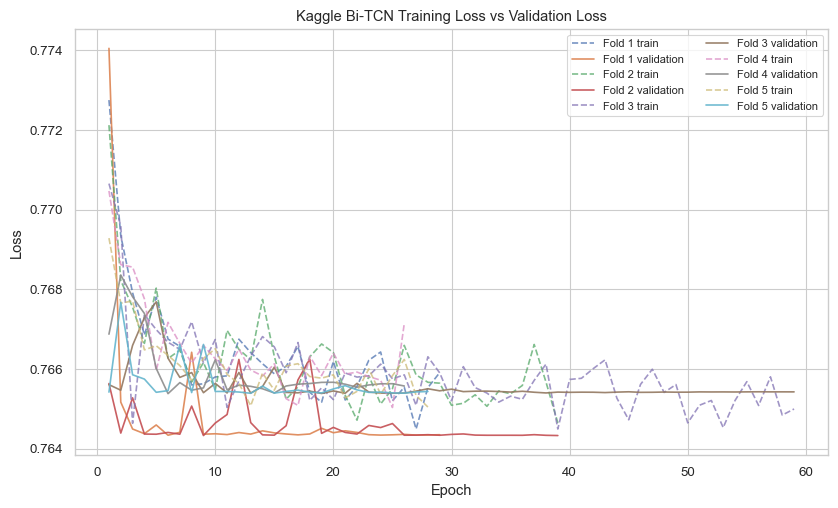

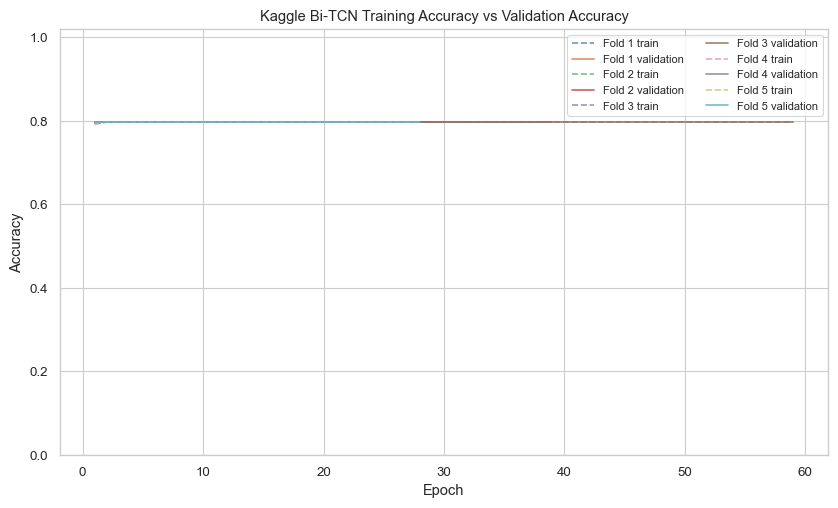

In [31]:
plt.figure(figsize=(8.5, 5.2))
for fold, hist in histories.items():
    plt.plot(hist["epoch"], hist["train_loss"], linestyle="--", alpha=0.75, label=f"Fold {fold} train")
    plt.plot(hist["epoch"], hist["val_loss"], alpha=0.9, label=f"Fold {fold} validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Kaggle Bi-TCN Training Loss vs Validation Loss")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "loss_validation_loss_diagram.png", dpi=300)
plt.show()

plt.figure(figsize=(8.5, 5.2))
for fold, hist in histories.items():
    plt.plot(hist["epoch"], hist["train_accuracy"], linestyle="--", alpha=0.75, label=f"Fold {fold} train")
    plt.plot(hist["epoch"], hist["val_accuracy"], alpha=0.9, label=f"Fold {fold} validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.02)
plt.title("Kaggle Bi-TCN Training Accuracy vs Validation Accuracy")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "accuracy_validation_accuracy_diagram.png", dpi=300)
plt.show()


## 10. Evaluation Visualizations


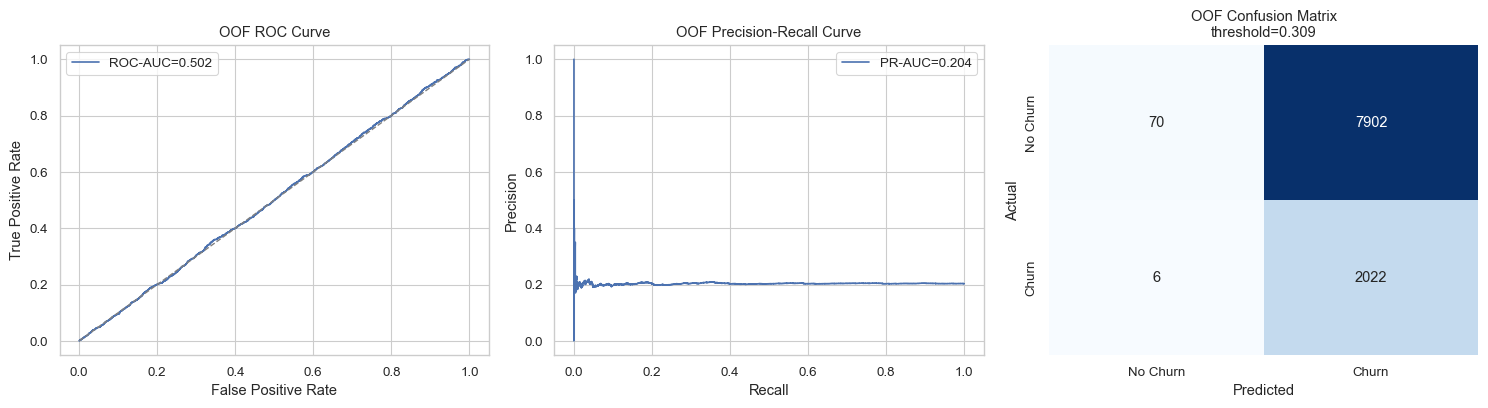

In [32]:
fpr, tpr, _ = roc_curve(y, oof_probs)
precision, recall, _ = precision_recall_curve(y, oof_probs)
cm = confusion_matrix(y, (oof_probs >= global_threshold).astype(int))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(fpr, tpr, label=f"ROC-AUC={oof_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("OOF ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall, precision, label=f"PR-AUC={oof_metrics['pr_auc']:.3f}")
axes[1].set_title("OOF Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2],
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
axes[2].set_title(f"OOF Confusion Matrix\nthreshold={global_threshold:.3f}")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "oof_evaluation_summary.png", dpi=300)
plt.show()


## 11. Output Files


In [33]:
print("Saved artifacts:")
for path in [
    OUTPUT_DIR / "config.json",
    OUTPUT_DIR / "fold_results.csv",
    OUTPUT_DIR / "metrics_summary.csv",
    OUTPUT_DIR / "oof_metrics.json",
    FIGURE_DIR / "loss_validation_loss_diagram.png",
    FIGURE_DIR / "accuracy_validation_accuracy_diagram.png",
    FIGURE_DIR / "oof_evaluation_summary.png",
]:
    print("-", path)

print("\nBest fold checkpoints:")
for path in sorted(MODEL_DIR.glob("best_model_fold_*.pth")):
    print("-", path)


Saved artifacts:
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_kaggle\config.json
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_kaggle\fold_results.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_kaggle\metrics_summary.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_kaggle\oof_metrics.json
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_kaggle\figures\loss_validation_loss_diagram.png
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_kaggle\figures\accuracy_validation_accuracy_diagram.png
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_kaggle\figures\oof_evaluation_summary.png

Best fold checkpoints:
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_kaggle\models\best_model_fold_1.pth
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_kaggle\m